# 🐻‍❄️ 투빅스 정규세션 4주차 1교시 Image Generative AI 코드 과제 🐻‍❄️



## 과제 목적
이번 과제에서는 이미지 생성 모델의 세 가지 큰 축인 **VAE**, **GAN**, **Diffusion**의 핵심 구현을 직접 코드로 뜯어보고, 마지막으로 Hugging Face의 사전학습 Diffusion 모델을 API처럼 불러와 실습해봅니다.
끝에는 직접 자기가 원하는 모델을 선택 후 써보는 경험까지 고안해보며 활용 능력까지 얻을 수 있도록 해봅니다.




## 제출물

1. 빈칸을 모두 채우고 **전부 실행한** 이 노트북 (출력 포함)
2. 기술블로그 '과제 복습' 섹션 — 마지막에 모델 활용한 [hugging face] question 4 부분만




- **VAE (Variational AutoEncoder)**: 입력 데이터를 확률적인 잠재 공간(latent space)으로 압축한 뒤, 그 분포에서 샘플링하여 새로운 데이터를 생성하는 모델
- **GAN (Generative Adversarial Network)**: Generator(위조지폐범)와 Discriminator(경찰)가 서로 경쟁하며 학습하는 모델
- **Diffusion Model**: 이미지에 점진적으로 노이즈를 주입(Forward process)한 뒤, 그 노이즈를 단계적으로 제거(Reverse process)하도록 학습하여 무작위 노이즈로부터 이미지를 생성하는 모델

Part 1~3에서는 세 모델을 MNIST로 직접 구현/학습하며 원리를 비교하고, Part 4에서는 Hugging Face `diffusers` 라이브러리로 실제 학습된 대형 Diffusion 모델을 실습합니다.


### **모듈 임포트 및 디바이스 설정**

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


### **데이터셋 준비 (MNIST dataset)**

In [4]:
batch_size = 128
epochs = 15

transform = transforms.Compose([
    transforms.ToTensor()
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# train / val split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)


100%|██████████| 9.91M/9.91M [00:02<00:00, 4.84MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 127kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.14MB/s]


## **Part 1. VAE (Variational AutoEncoder) 모델 정의 및 학습**

* Encoder: 입력 데이터 x를 받아 잠재 공간(Latent Space)의 파라미터를 추출
  * 고차원의 입력데이터를 저차원의 평균과 로그 분산으로 변환
    * 💡 빈칸 채우기 hint) `self.fc1`을 거쳐 특징을 추출한 뒤, 두 개의 서로 다른 선형 레이어를 통해 각각 평균과 로그 분산을 계산

* Latent Space & Reparameterization
  * 잠재 변수 z를 직접 고정된 값으로 뽑는 것이 아니라, encoder가 만든 분포(평균, 로그 분산)에서 샘플링함
  * Reparameterization Trick: backpropagation는 샘플링 연산을 통과할 수 없다는 문제를 해결하기 위해 샘플링 과정을 미분 가능한 형태로 만들기 위한 수식

* Decoder
  * 샘플링된 잠재 변수 z를 다시 원래의 입력 데이터 차원으로 복원


참고 코드: https://github.com/NoviceStone/VAE/blob/master/models.py

In [5]:
class VAE(nn.Module):

    def __init__(self, input_size=784, hidden_size=400, latent_size=20):
        super(VAE, self).__init__()

        # Encoder: layers
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc21 = nn.Linear(hidden_size, latent_size)  # 평균(mu)
        self.fc22 = nn.Linear(hidden_size, latent_size)  # 로그 분산(logvar)

        # Decoder: layers
        self.fc3 = nn.Linear(latent_size, hidden_size)
        self.fc4 = nn.Linear(hidden_size, input_size)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        mu = self.fc21(h1)   # 🤔 빈칸을 채워주세요 (h1을 받아 평균을 계산하는 레이어)
        logvar = self.fc22(h1)   # 🤔 빈칸을 채워주세요 (h1을 받아 로그 분산을 계산하는 레이어)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std   # 🤔 빈칸을 채워주세요 (Reparameterization Trick 수식)

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


**✍️ 위에서 채운 `encode` / `reparameterize` 코드가 각각 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* encode 함수는 입력 데이터 x를 잠재 공간의 확률분포로 변환하는 역할을 한다
코드적으로는 하나의 은닉 표현 h1을 만든 후, 이를 두 개의 출력층으로 나누어 평균과 분산 정보를 각각 출력하는 구조이다
reparameterize 함수는 encode에서 계산한 평균과 로그 분산을 이용해 실제 잠재 변수 z를 생성하는 역할을 한다 코드적으로는 랜덤 샘플링 부분을 eps로 분리하는 Reparameterization Trick을 사용하여, 샘플링 과정이 포함되어 있어도 역전파를 통해 모델을 학습할 수 있도록 구성되어 있다

### **VAE loss (ELBO)**
* Reconstruction Loss: 복원된 이미지(`recon_x`)가 원본 이미지(`x`)와 얼마나 다른지 측정
* KL Divergence: 잠재공간의 분포가 표준 정규분포와 얼마나 다른지 측정


In [6]:
def elbo_loss(x, recon_x, mu, logvar):

    B = x.size(0)

    x = x.view(-1, 784)

    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum') / B  # 🤔 빈칸을 채워주세요

    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / B  # 🤔 빈칸을 채워주세요

    total_loss = BCE + KLD  # 🤔 빈칸을 채워주세요

    return total_loss


**✍️ 위에서 채운 `elbo_loss` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

*elbo_loss는 원본 입력과 복원 결과의 차이를 계산하는 BCE와, 잠재분포가 표준정규분포에 가까워지도록 하는 KLD를 함께 계산하는 함수이다
코드적으로는 BCE + KLD를 최종 손실값으로 사용하여 복원 성능과 잠재 공간의 정규화를 동시에 학습하도록 구성되어 있다


## **🙋 [VAE] Question 1**
VAE의 ELBO Loss에 KL Divergence 항이 포함되는 이유를 설명해주세요.



*


In [7]:
vae = VAE().to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

for epoch in range(epochs):

    # ========== Train ==========
    vae.train()
    train_loss = 0

    for x, _ in train_loader:

        x = x.to(device)

        recon, mu, logvar = vae(x)

        loss = elbo_loss(x, recon, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_dataset)

    # ========== Validation ==========
    vae.eval()
    val_loss = 0

    with torch.no_grad():
        for x, _ in val_loader:
            x = x.to(device)
            recon, mu, logvar = vae(x)
            loss = elbo_loss(x, recon, mu, logvar)
            val_loss += loss.item()

    val_loss /= len(val_dataset)

    print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")


Epoch [1/15] Train Loss: 1.3230 | Val Loss: 1.0281
Epoch [2/15] Train Loss: 0.9672 | Val Loss: 0.9247
Epoch [3/15] Train Loss: 0.9054 | Val Loss: 0.8951
Epoch [4/15] Train Loss: 0.8787 | Val Loss: 0.8706
Epoch [5/15] Train Loss: 0.8638 | Val Loss: 0.8596
Epoch [6/15] Train Loss: 0.8535 | Val Loss: 0.8513
Epoch [7/15] Train Loss: 0.8460 | Val Loss: 0.8454
Epoch [8/15] Train Loss: 0.8405 | Val Loss: 0.8403
Epoch [9/15] Train Loss: 0.8363 | Val Loss: 0.8369
Epoch [10/15] Train Loss: 0.8324 | Val Loss: 0.8351
Epoch [11/15] Train Loss: 0.8291 | Val Loss: 0.8309
Epoch [12/15] Train Loss: 0.8265 | Val Loss: 0.8305
Epoch [13/15] Train Loss: 0.8247 | Val Loss: 0.8274
Epoch [14/15] Train Loss: 0.8222 | Val Loss: 0.8261
Epoch [15/15] Train Loss: 0.8204 | Val Loss: 0.8241


**VAE sampling 시각화**

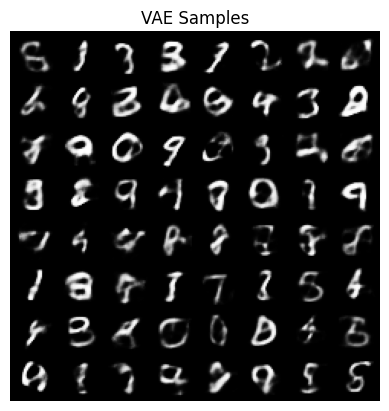

In [8]:
with torch.no_grad():

    z = torch.randn(64, 20).to(device)

    samples = vae.decode(z).view(-1, 1, 28, 28)

    grid = make_grid(samples, 8)

plt.imshow(grid.permute(1, 2, 0).cpu())
plt.title("VAE Samples")
plt.axis("off")
plt.show()


## **Part 2. DCGAN (Deep Convolutional GAN) 모델 정의 및 학습**
- Weight Initialization
  - 모델의 가중치는 평균이 0, 표준편차가 0.02인 정규분포로 초기화
  - 기존 GAN의 학습 불안정성을 줄이기 위해 DCGAN 논문에서 제안한 아이디어

- Generator (생성자)
  - Transposed Convolution: 저차원의 잠재 벡터를 고해상도 이미지로 확장
  - Batch Normalization: 각 layer의 출력을 정규화하여 학습의 안정성을 높이고 gradient vanishing 문제를 해결
  - Activation: 중간 layer에는 ReLU를 통해 빠른 학습을 진행하고, 마지막 layer에는 이미지의 픽셀 값 범위([-1, 1])를 맞추기 위해 Tanh를 사용

- Discriminator (판별자)
  - Strided Convolution: pooling 대신 stride를 사용하여 특징을 추출
  - 마지막 layer에서 sigmoid를 통해 Real/Fake 확률값 출력


참고 코드: https://github.com/Natsu6767/DCGAN-PyTorch/blob/master/dcgan.py

In [9]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # [-1, 1]
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# train / val split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)


In [10]:
# weight 초기화 함수

def weights_init(m):

    classname = m.__class__.__name__

    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


In [11]:
latent_size = 20

class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.tconv1 = nn.ConvTranspose2d(latent_size, 256, 7, 1, 0, bias=False)
        self.bn1 = nn.BatchNorm2d(256)

        self.tconv2 = nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(128)

        self.tconv3 = nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(64)

        self.tconv4 = nn.ConvTranspose2d(64, 1, 3, 1, 1, bias=False)

    def forward(self, z):
        x = F.relu(self.bn1(self.tconv1(z)))   # 🤔 빈칸을 채워주세요 (Generator의 입력)
        x = F.relu(self.bn2(self.tconv2(x)))
        x = F.relu(self.bn3(self.tconv3(x)))
        x = torch.tanh(self.tconv4(x))   # 🤔 빈칸을 채워주세요 (마지막 layer 통과)
        return x


**✍️ 위에서 채운 `Generator.forward` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* Generator.forward는 잠재 벡터 z를 입력받아 여러 개의 전치 합성곱 층을 거치며 크기를 점점 키워 최종 이미지를 생성하는 역할을 한다
코드적으로는 중간 층에 ConvTranspose2d + BatchNorm + ReLU를 사용하고, 마지막 층에서는 tanh를 적용해 생성 이미지의 출력값을 정해진 범위로 맞추도록 구성되어 있다


In [12]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=4, stride=2, padding=1, bias=False)

        self.conv2 = nn.Conv2d(64, 128, 4, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(128)

        self.conv3 = nn.Conv2d(128, 256, 4, 2, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(256)

        self.conv4 = nn.Conv2d(256, 1, 3, 1, 0, bias=False)

    def forward(self, x):

        x = F.leaky_relu(self.conv1(x), 0.2)
        x = F.leaky_relu(self.bn2(self.conv2(x)), 0.2)
        x = F.leaky_relu(self.bn3(self.conv3(x)), 0.2)   # 🤔 빈칸을 채워주세요 (conv3 + bn3 통과)
        x = torch.sigmoid(self.conv4(x))

        return x.view(-1, 1).squeeze(1)


**✍️ 위에서 채운 `Discriminator.forward` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* Discriminator.forward는 입력 이미지가 실제 이미지인지 Generator가 만든 가짜 이미지인지 판별하는 역할을 한다
코드적으로는 Conv2d + BatchNorm + LeakyReLU를 반복해 이미지 특징을 추출하고 마지막에 sigmoid를 적용해 실제 이미지일 확률을 출력하도록 구성되어 있다


In [13]:
G = Generator().to(device)
D = Discriminator().to(device)

G.apply(weights_init)
D.apply(weights_init)

criterion = nn.BCELoss()

optG = optim.Adam(G.parameters(), 0.0002, betas=(0.5, 0.999))
optD = optim.Adam(D.parameters(), 0.0002, betas=(0.5, 0.999))


In [14]:
for epoch in range(epochs):

    G.train()
    D.train()

    train_lossD = 0
    train_lossG = 0

    for x, _ in train_loader:

        x = x.to(device)

        real = torch.ones(x.size(0)).to(device)
        fake = torch.zeros(x.size(0)).to(device)

        # ========== Train Discriminator ==========

        z = torch.randn(x.size(0), latent_size, 1, 1).to(device)

        fake_img = G(z)

        loss_real = criterion(D(x), real)
        loss_fake = criterion(D(fake_img.detach()), fake)

        lossD = loss_real + loss_fake

        optD.zero_grad()
        lossD.backward()
        optD.step()

        # ========== Train Generator ==========

        loss_G = criterion(D(fake_img), real)  # 🤔 빈칸을 채워주세요 (Generator는 D가 fake_img를 무엇으로 착각하길 원할까요?)

        optG.zero_grad()
        loss_G.backward()
        optG.step()

        train_lossD += lossD.item()
        train_lossG += loss_G.item()

    train_lossD /= len(train_loader)
    train_lossG /= len(train_loader)

    print(f"Epoch [{epoch+1}/{epochs}] Loss D: {train_lossD:.4f} | Loss G: {train_lossG:.4f}")


Epoch [1/15] Loss D: 0.8130 | Loss G: 1.7159
Epoch [2/15] Loss D: 0.9406 | Loss G: 1.4160
Epoch [3/15] Loss D: 0.9782 | Loss G: 1.3437
Epoch [4/15] Loss D: 1.0093 | Loss G: 1.3188
Epoch [5/15] Loss D: 1.0151 | Loss G: 1.3287
Epoch [6/15] Loss D: 1.0352 | Loss G: 1.3017
Epoch [7/15] Loss D: 1.0418 | Loss G: 1.3206
Epoch [8/15] Loss D: 1.0305 | Loss G: 1.3175
Epoch [9/15] Loss D: 1.0367 | Loss G: 1.3305
Epoch [10/15] Loss D: 1.0153 | Loss G: 1.3691
Epoch [11/15] Loss D: 1.0088 | Loss G: 1.3783
Epoch [12/15] Loss D: 0.9993 | Loss G: 1.4017
Epoch [13/15] Loss D: 0.9801 | Loss G: 1.4293
Epoch [14/15] Loss D: 1.0016 | Loss G: 1.4261
Epoch [15/15] Loss D: 0.9647 | Loss G: 1.4591


**✍️ 위에서 채운  코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

*
위 코드는 Discriminator와 Generator를 번갈아 학습시키는 GAN의 전체 학습 과정이다
코드적으로는 먼저 Discriminator가 실제 이미지와 가짜 이미지를 구분하도록 학습한 뒤 Generator가 만든 이미지를 Discriminator가 실제라고 판단하도록 real 값을 목표로 하여 Generator를 업데이트하도록 구성되어 있다

**DCGAN Sampling 시각화**

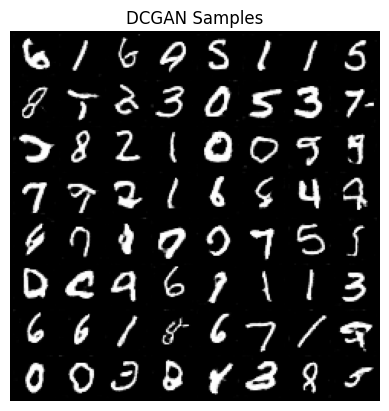

In [15]:
G.eval()

with torch.no_grad():

    z = torch.randn(64, latent_size, 1, 1).to(device)

    samples = G(z)

grid = make_grid(samples, 8, normalize=True)

plt.imshow(grid.permute(1, 2, 0).cpu())
plt.title("DCGAN Samples")
plt.axis("off")
plt.show()


## **🙋 [GAN] Question 1**
VAE와 DCGAN으로 MNIST 이미지를 생성한 결과 VAE는 흐릿한 이미지, DCGAN은 선명한 이미지가 생성된 것을 알 수 있습니다. 그 이유를 VAE와 GAN의 특징과 학습 방식을 포함하여 설명해주세요.

* VAE는 입력 데이터를 확률분포로 표현하고 재구성 손실과 KL Divergence를 함께 최소화하며 학습하기 때문에 전체적으로 평균적인 특징을 학습하는 경향이 있어 생성 이미지가 다소 흐릿해질 수 있는 반면에 반면 GAN은 Generator와 Discriminator가 서로 경쟁하며 학습하고, Generator가 Discriminator를 속일 수 있을 만큼 실제와 비슷한 이미지를 생성하도록 직접 학습하기 때문에 상대적으로 더 선명한 이미지를 생성할 수 있다


## **🙋 [GAN] Question 2**
GAN 학습 과정에서 Generator와 Discriminator 중 한쪽이 너무 빨리 강해지면 어떤 문제가 발생할 수 있는지, Mode collapse 또는 Vanishing gradient 개념을 활용하여 설명해주세요.

*Discriminator가 너무 빨리 강해지면 가짜 이미지를 너무 쉽게 구분하여 Generator에 전달되는 gradient가 매우 작아지는 Vanishing Gradient가 발생할 수 있고 이로 인해 Generator의 학습이 제대로 진행되지 않는다 반대로 Generator의 학습이 불안정하거나 특정 패턴만으로 Discriminator를 속이게 되면 다양한 이미지를 만들지 않고 비슷한 이미지만 반복해서 생성하는 Mode Collapse가 발생할 수 있다


## **Part 3. Diffusion Model (DDPM) 원리 구현**

- **Forward process**: 원본 이미지 $x_0$에 $t$번에 걸쳐 점진적으로 Gaussian noise를 주입하여 $x_t$를 만드는 과정. Closed-form으로 한 번에 임의의 t 시점 노이즈 이미지를 계산할 수 있음
  $$x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1-\bar{\alpha}_t}\, \epsilon,\quad \epsilon \sim \mathcal{N}(0, I)$$

- **Reverse process**: 노이즈 $x_t$로부터 노이즈 $\epsilon$을 예측하는 신경망(주로 U-Net)을 학습시켜, $x_T$(순수 노이즈)부터 $x_0$까지 역으로 복원

- **손실함수의 단순화**: DDPM 논문의 핵심 기여 중 하나로, 복잡한 분포 비교 대신 신경망이 예측한 노이즈와 실제 주입된 노이즈 사이의 단순 MSE Loss만으로 학습이 가능함
  $$L_{simple} = \mathbb{E}_{t, x_0, \epsilon}\left[\, \| \epsilon - \epsilon_\theta(x_t, t) \|^2 \,\right]$$

이번 파트에서는 **forward process와 손실함수, 노이즈 예측 네트워크의 핵심 구조를 직접 코드로 구현**하며 원리를 이해합니다. 다만 DDPM은 실제로는 대규모 U-Net을 오랜 시간 학습해야 제대로 된 이미지가 나오기 때문에, 짧은 실습 환경(Colab)에서 처음부터 학습시키기엔 한계가 있습니다. 그래서 우리가 구현한 것과 동일한 원리로 학습된 **Hugging Face의 사전학습 MNIST DDPM 모델**을 불러와 실제 reverse process 결과를 확인해봅니다.


In [16]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # [-1, 1]
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)


### **Noise Schedule 정의**
$\beta_t$를 선형으로 증가시키며, $\alpha_t = 1-\beta_t$, $\bar{\alpha}_t = \prod_{s=1}^{t}\alpha_s$ 를 미리 계산해둡니다.


In [17]:
T = 1000  # DDPM 논문 기준 총 diffusion step 수

beta_start = 1e-4
beta_end = 0.02

betas = torch.linspace(beta_start, beta_end, T).to(device)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)


def forward_diffusion(x0, t):
    """x0(원본 이미지)에 timestep t만큼의 노이즈를 주입해 x_t를 반환"""
    noise = torch.randn_like(x0)

    sqrt_ac = sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
    sqrt_omac = sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)

    x_t = sqrt_ac * x0 + sqrt_omac * noise   # 🤔 빈칸을 채워주세요 (forward process 수식)

    return x_t, noise


**✍️ 위에서 채운 `forward_diffusion` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* forward_diffusion은 원본 이미지 x0에 timestep t에 맞는 가우시안 노이즈를 추가하여 노이즈가 섞인 이미지 x_t를 생성하는 함수이다
코드적으로는 sqrt_ac와 sqrt_omac를 이용해 원본 이미지와 노이즈의 비율을 조절하고 DDPM의 forward process 수식을 그대로 구현하도록 구성되어 있다


**Forward process 시각화**: t가 커질수록 이미지가 점점 순수 노이즈에 가까워지는 것을 확인해봅시다.

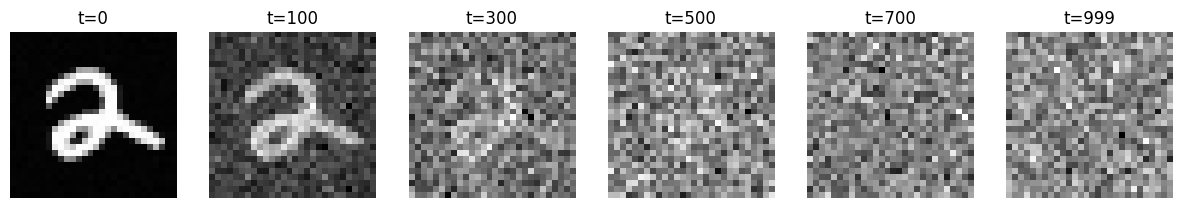

In [18]:
x0, _ = next(iter(train_loader))
x0 = x0[:1].to(device)

timesteps_to_show = [0, 100, 300, 500, 700, 999]
fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(15, 3))

for i, t_val in enumerate(timesteps_to_show):
    t = torch.tensor([t_val]).to(device)
    x_t, _ = forward_diffusion(x0, t)
    axes[i].imshow(x_t[0, 0].cpu().numpy(), cmap="gray")
    axes[i].set_title(f"t={t_val}")
    axes[i].axis("off")

plt.show()


### **U-Net 기반 노이즈 예측 네트워크**
DDPM은 노이즈가 섞인 이미지 $x_t$와 timestep $t$를 입력받아 주입된 노이즈 $\epsilon$을 예측하는 신경망을 사용합니다. 아래는 skip connection을 포함한 축소된 U-Net 구조입니다. Downsampling에서 저장해둔 feature map을 Upsampling 단계에서 다시 이어붙여(concat), 공간 정보 손실을 줄이는 것이 핵심입니다.


In [19]:
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        emb = np.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        return emb


class SimpleUNet(nn.Module):

    def __init__(self, time_dim=64):
        super().__init__()

        self.time_mlp = nn.Sequential(
            TimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.ReLU()
        )

        # Downsampling
        self.down1 = nn.Conv2d(1, 64, 3, padding=1)                    # 28 -> 28
        self.down2 = nn.Conv2d(64, 128, 3, stride=2, padding=1)        # 28 -> 14
        self.down3 = nn.Conv2d(128, 256, 3, stride=2, padding=1)       # 14 -> 7

        self.time_proj = nn.Linear(time_dim, 256)

        # Bottleneck
        self.bottleneck = nn.Conv2d(256, 256, 3, padding=1)            # 7 -> 7

        # Upsampling (skip connection으로 채널이 2배가 됨)
        self.up1 = nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1)   # 7 -> 14
        self.up_conv1 = nn.Conv2d(128 + 128, 128, 3, padding=1)           # skip(h2) concat

        self.up2 = nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1)    # 14 -> 28
        self.up_conv2 = nn.Conv2d(64 + 64, 64, 3, padding=1)              # skip(h1) concat

        self.out = nn.Conv2d(64, 1, 3, padding=1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        # Downsampling (skip connection용으로 각 단계 출력을 저장)
        h1 = F.relu(self.down1(x))      # (B, 64, 28, 28)
        h2 = F.relu(self.down2(h1))     # (B, 128, 14, 14)
        h3 = F.relu(self.down3(h2))     # (B, 256, 7, 7)

        # timestep embedding을 bottleneck 채널에 더해줌
        t_proj = self.time_proj(t_emb).unsqueeze(-1).unsqueeze(-1)
        h3 = h3 + t_proj   # 🤔 빈칸을 채워주세요 (h3에 timestep 정보를 더해주려면?)

        h3 = F.relu(self.bottleneck(h3))

        # Upsampling + skip connection (concat)
        u1 = F.relu(self.up1(h3))                      # (B, 128, 14, 14)
        u1 = torch.cat([u1, h2], dim=1)                 # (B, 256, 14, 14)
        u1 = F.relu(self.up_conv1(u1))                  # (B, 128, 14, 14)

        u2 = F.relu(self.up2(u1))                       # (B, 64, 28, 28)
        u2 = torch.cat([u2, h1], dim=1)                  # (B, 128, 28, 28)
        u2 = F.relu(self.up_conv2(u2))                   # (B, 64, 28, 28)

        out = self.out(u2)

        return out


**✍️ 위에서 채운 `SimpleUNet.forward`의 timestep 결합 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* SimpleUNet.forward의 timestep 결합 부분은 현재 이미지가 diffusion 과정의 몇 번째 단계에 있는지에 대한 정보를 U-Net에 전달하는 역할을 한다
코드적으로는 timestep t를 임베딩한 뒤 Linear 층으로 256차원에 맞추고 공간 차원을 추가한 t_proj를 bottleneck 특징맵 h3에 더하도록 구성되어 있다


### **DDPM Loss**
예측한 노이즈와 실제 주입한 노이즈 사이의 MSE Loss입니다.


In [20]:
def ddpm_loss(model, x0):
    B = x0.size(0)

    t = torch.randint(0, T, (B,), device=device).long()

    x_t, noise = forward_diffusion(x0, t)

    predicted_noise = model(x_t, t)

    loss = F.mse_loss(predicted_noise, noise)   # 🤔 빈칸을 채워주세요 (실제 노이즈 vs 예측 노이즈)

    return loss


**✍️ 위에서 채운 `ddpm_loss` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

*ddpm_loss는 실제로 추가된 노이즈와 모델이 예측한 노이즈의 차이를 계산해서, 모델이 노이즈를 잘 예측하도록 학습하는 함수이다
코드적으로는 랜덤 timestep을 선택해 x_t를 만든 뒤 model(x_t, t)의 예측 노이즈와 실제 noise 사이의 MSE를 loss로 사용하도록 구성되어 있다


## **🙋 [Diffusion] Question 1**
DDPM은 왜 원본 이미지 $x_0$를 직접 예측하지 않고, 이미지에 주입된 노이즈 $\epsilon$을 예측하도록 학습할까요?

* DDPM은 각 timestep에서 이미지에 추가된 노이즈 \(\epsilon\)를 예측하도록 학습하면 모든 단계에서 비교적 일관된 형태의 목표값을 사용할 수 있어 학습이 더 안정적이다 또한 예측한 노이즈를 제거하는 과정을 반복하면 \(x_t\)에서 점차 깨끗한 이미지를 복원할 수 있기 때문에 최종적으로 \(x_0\)를 직접 예측하지 않아도 원본 이미지 생성이 가능하다


In [21]:
unet = SimpleUNet().to(device)

# 참고: 위에서 구현한 forward_diffusion / SimpleUNet / ddpm_loss가
# DDPM 학습의 핵심 원리 전부입니다. 다만 실제로 눈에 보이는 숫자 이미지를
# 생성할 수준까지 학습시키려면 훨씬 더 큰 모델과 긴 학습 시간이 필요합니다.
# 아래에서는 동일한 원리로 이미 충분히 학습된 사전학습 모델을 불러와
# reverse process 결과를 직접 확인해봅니다.


### **사전학습된 DDPM으로 Reverse Process 결과 확인**

Hugging Face에는 우리가 위에서 구현한 것과 동일한 원리(forward process, 노이즈 예측 U-Net, MSE loss)로 MNIST를 학습시킨 DDPM 모델이 공개되어 있습니다. `DDPMPipeline`을 불러와 실제 reverse process가 어떻게 노이즈에서 숫자 이미지를 만들어내는지 확인해봅시다.


In [22]:
!pip install -q diffusers transformers accelerate safetensors

model_index.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

FrozenDict({'num_train_timesteps': 1000, 'beta_start': 0.0001, 'beta_end': 0.02, 'beta_schedule': 'squaredcos_cap_v2', 'trained_betas': None, 'variance_type': 'fixed_small', 'clip_sample': True, 'prediction_type': 'epsilon', 'thresholding': False, 'dynamic_thresholding_ratio': 0.995, 'clip_sample_range': 1.0, 'sample_max_value': 1.0, 'timestep_spacing': 'leading', 'steps_offset': 0, 'rescale_betas_zero_snr': False, '_class_name': 'DDPMScheduler', '_diffusers_version': '0.27.2'})


  0%|          | 0/200 [00:00<?, ?it/s]

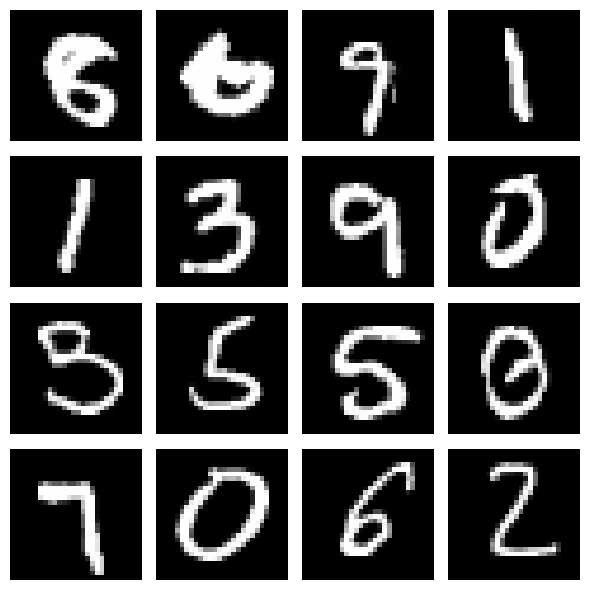

In [23]:
import torch
import matplotlib.pyplot as plt
from diffusers import DDPMPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"

pipe = DDPMPipeline.from_pretrained(
    "nathanReitinger/MNIST-diffusion"
).to(device)

# Scheduler 설정 확인
print(pipe.scheduler.config)

# Reverse process
images = pipe(
    batch_size=16,
    num_inference_steps=200
).images

# 결과 확인
fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for ax, image in zip(axes.flatten(), images):
    ax.imshow(image, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()

### 별도 question!
결과가 이상하게 나와서 당황하셨죠?
왜 ddpm은 앞의 vae와 gan과 다르게 일관적이지 않고 어떤건 바르게 어떤 건 완전 악필이 쓴 것처럼 나오는 걸까요?

-DDPM은 랜덤 노이즈에서 시작해 여러 단계에 걸쳐 노이즈를 제거하므로, 각 단계의 예측 오차가 누적되면 일부 이미지의 형태가 흐트러질 수 있다 또한 unconditional generation과 제한된 inference step 때문에 매번 생성 결과가 달라지며 학습이 충분하지 않은 모델에서는 일부 숫자가 악필처럼 생성될 수 있다

## **🙋 [Diffusion] Question 2**
VAE, GAN, Diffusion 세 모델을 **학습 안정성**, **생성 품질**, **추론(샘플링) 속도** 세 가지 관점에서 비교해주세요.

앞선 실습 사진을 보고 하는 것이 아닌 이론적으로 비교해주시면 됩니다.아무래도 실습이다보니 이 결과로 비교하는 것은 이론적으로 틀릴 수도 있어서...

VAE는 학습이 안정적이고 샘플링도 빠르지만 생성 이미지가 다소 흐릿해질 수 있다 GAN은 선명한 이미지를 빠르게 생성할 수 있지만 Generator와 Discriminator의 균형 문제로 학습이 불안정할 수 있다 Diffusion은 노이즈 예측 기반 학습으로 비교적 안정적이며 높은 품질의 이미지를 생성하지만 여러 단계의 denoising을 반복해야 해서 샘플링 속도가 가장 느리다



## **Part 4. Hugging Face `diffusers`로 사전학습 Diffusion 모델 실습**

Part 3에서 우리는 DDPM의 핵심 원리(forward process, 노이즈 예측 U-Net, MSE loss)를 직접 코드로 구현하고, MNIST 전용 사전학습 모델로 그 결과를 확인해봤습니다. 이번에는 훨씬 크고 복잡한 U-Net을 방대한 이미지-텍스트 데이터로 학습시킨 모델을 다뤄봅니다. 대표적으로 **Stable Diffusion**은 발표자료에서 다룬 것처럼 VAE + Diffusion(Latent Diffusion) + Cross-Attention 기반 Text Conditioning 구조를 가지고 있습니다.

Hugging Face의 `diffusers` 라이브러리를 사용하면 이런 사전학습 모델을 몇 줄의 코드로 불러와 사용할 수 있습니다. Colab에서는 **런타임 유형을 GPU로 설정**한 후 진행해주세요. (런타임 → 런타임 유형 변경 → T4 GPU)


In [24]:
!pip install -q diffusers transformers accelerate


### **4-1. Text-to-Image: Stable Diffusion**

프롬프트를 입력하면 그에 맞는 이미지를 생성해주는 `StableDiffusionPipeline`을 사용해봅니다. 내부적으로는 텍스트 프롬프트를 CLIP text encoder로 임베딩하고, 이를 조건으로 latent space에서 diffusion(denoising)을 수행한 뒤, VAE decoder로 pixel space 이미지를 복원합니다. (발표자료 33p의 Stable Diffusion 구조 참고)


In [25]:
import torch
from diffusers import StableDiffusionPipeline

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)
pipe = pipe.to("cuda")


/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

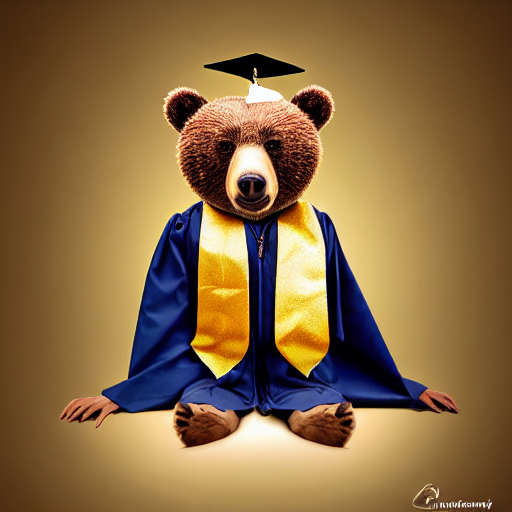

In [26]:
prompt = "a photo of a bear wearing a graduation cap, studio lighting, high quality"   # 🤔 원하는 프롬프트로 자유롭게 바꿔보세요

image = pipe(
    prompt,
    num_inference_steps=100,   # 🤔 빈칸을 채워주세요 (몇 step 만에 denoising을 마칠지, 예: 25~50)
    guidance_scale=7.5
).images[0]

image


**✍️ 위에서 채운 `num_inference_steps` 코드가 어떤 기능을 하고, 이 값이 커지거나 작아지면 결과가 어떻게 달라지는지 간단히 설명해주세요.**

*
num_inference_steps는 Stable Diffusion이 랜덤 노이즈에서 이미지를 생성할 때 몇 번의 denoising 과정을 반복할지 정하는 값이다
값이 커지면 보통 더 많은 단계를 거쳐 이미지 품질이 좋아질 수 있지만 생성 시간이 길어지고 값이 작아지면 생성 속도는 빨라지지만 이미지 품질이나 세부 표현이 떨어질 수 있다 이 실습에서 볼 수 있듯이 25로 했을때는 곰이 모자도 안쓰고 디테일이 많이 떨어지지만 100정도만 해도 곰이 모자도 쓰고 옷도입은 디테일잇는 모습으로 나타난다

## **🙋 [Hugging Face] Question 1**
위 코드의 `guidance_scale` 파라미터는 발표자료의 **Classifier-free guidance(CFG)** 개념과 관련이 있습니다. `guidance_scale` 값을 낮추거나(예: 1.0) 높이면(예: 15.0) 생성 결과가 각각 어떻게 달라질지 예상해보고, 실제로 두 값으로 각각 이미지를 생성해 비교해주세요.

*


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

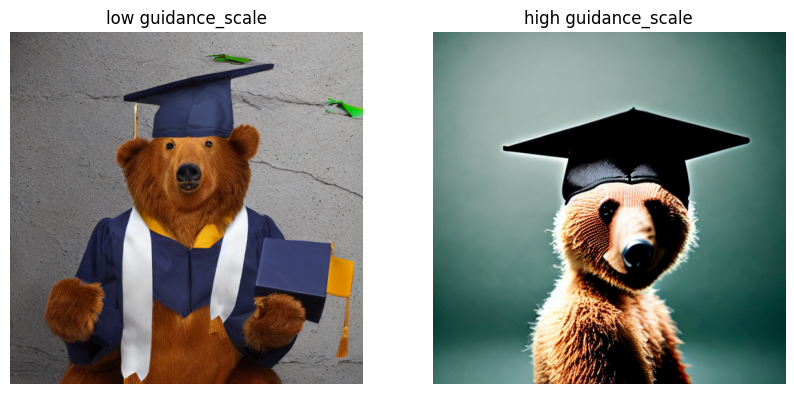

In [27]:
# 🤔 guidance_scale을 다르게 주어 두 이미지를 생성하고 비교해주세요
prompt = "a photo of a bear wearing a graduation cap, studio lighting, high quality"

image_low_cfg = pipe(prompt, num_inference_steps=30, guidance_scale=3.0).images[0]   # 🤔 빈칸을 채워주세요
image_high_cfg = pipe(prompt, num_inference_steps=30, guidance_scale=12.0).images[0]  # 🤔 빈칸을 채워주세요

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image_low_cfg)
axes[0].set_title("low guidance_scale")
axes[0].axis("off")
axes[1].imshow(image_high_cfg)
axes[1].set_title("high guidance_scale")
axes[1].axis("off")
plt.show()


**✍️ 위에서 채운 `guidance_scale` 비교 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

*
guidance_scale 비교 코드는 같은 프롬프트로 이미지를 두 번 생성하되, 프롬프트를 따르는 강도를 다르게 설정하여 생성 결과의 차이를 확인하는 기능을 한다.
코드적으로는 guidance_scale 값만 각각 낮게 높게 줘서 두 이미지를 만든 뒤, matplotlib으로 나란히 출력하여 조건 반영 정도를 비교하도록 구성되어 있다. 실제 비교시에 퀄리티의 차이를 볼 수 있다

### **4-2. Sampler(Scheduler) 교체해보기**

발표자료 33p에서 언급했듯 Stable Diffusion은 하나로 고정된 모델이 아니라, denoising에 사용하는 sampler(scheduler)를 자유롭게 교체할 수 있는 구조입니다. 기본 스케줄러 대신 DDIM 스케줄러로 교체하여 더 적은 step으로도 이미지를 생성해봅니다.


  0%|          | 0/20 [00:00<?, ?it/s]

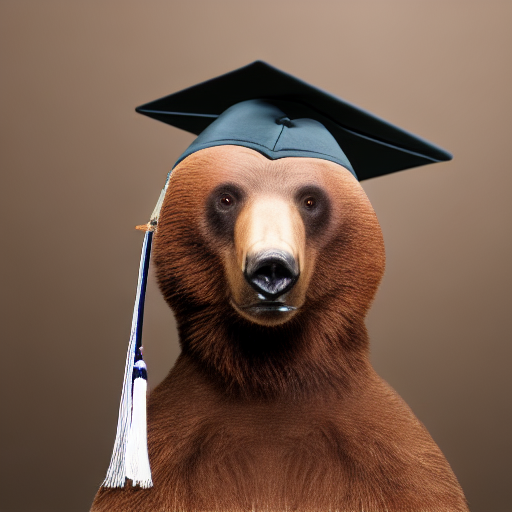

In [28]:
from diffusers import DDIMScheduler

pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

image_ddim = pipe(
    prompt,
    num_inference_steps=20,  # DDPM보다 훨씬 적은 step
    guidance_scale=7.5
).images[0]

image_ddim


## **🙋 [Hugging Face] Question 2**
DDIM 스케줄러가 기본 스케줄러보다 적은 step으로도 그럴듯한 이미지를 생성할 수 있는 이유를 Part 3에서 다룬 DDPM의 reverse process와 비교하여 설명해주세요.

*DDPM의 reverse process는 각 timestep에서 확률적으로 한 단계씩 노이즈를 제거하므로 많은 step이 필요하다 반면 DDIM은 예측한 노이즈를 바탕으로 여러 단계를 건너뛰어도 이전 이미지를 추정할 수 있는 더 효율적인 샘플링 방식을 사용하므로 적은 step으로도 비교적 좋은 품질의 이미지를 생성할 수 있다


## **🙋 [Hugging Face] Question 3**
직접 해보기 + 허깅 페이스와 인사하기

허깅페이스의 모델 api 활용하기/space에서 모델 3개 이상 활용해보기
둘 중 하나를 택해서 실행하고 간단하게 써본 경험을 공유해주세요!

[예시 노션 링크](https://app.notion.com/p/Hugging-face-3a059e60d52d80f49489f7a3c3ef6648?source=copy_link)

실제로 spacae에서 모델을 3개정도 찾아서 봤는데 이미지 생성 음성 인식 번역처럼 서로 다른 종류의 AI 모델을 Hugging Face에서 쉽게 활용해 볼 수 있다는 점이 인상적이었다


## 생성형 AI 활용 (비판적 사용)

AI는 **검산기·설명 도우미**로 활용하고 최종 판단은 본인이 합니다.

- **어디에 썼나** (PyTorch 문법 디버깅·개념 설명·에러 해석 등 구체적으로): (여기에 답) 문법 개념 빈칸채우기

- **AI가 이 실험에는 틀린 답을 준 사례** —
  본인이 겪은 사례와, 그것을 **어떻게 알아채고 고쳤는지**(본인 출력값과 대조 / 공식 문서 확인 / 직접 실험) 적으세요: 대부분 코드 값에 관련된 질문을 해서 딱히 틀린 값은 존재하지 않았다

- **실제 대화 내역** 붙여넣기:

```
(여기에 AI와의 실제 대화 내역을 붙여넣기)
```def elbo_loss(x, recon_x, mu, logvar):
    B = x.size(0)
    x = x.view(-1, 784)

    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum') / B
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / B

    total_loss = BCE + KLD

    return total_loss



    ### 빈칸 코드

```python
def encode(self, x):
    h1 = F.relu(self.fc1(x))

    mu = self.fc21(h1)
    logvar = self.fc22(h1)

    return mu, logvar


def reparameterize(self, mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)

    return mu + eps * std
```

### `encode` 함수

`encode` 함수는 입력 데이터 `x`를 잠재 공간(latent space)의 확률분포로 변환하는 역할을 한다.

먼저,

```python
h1 = F.relu(self.fc1(x))
```

를 통해 입력 데이터를 은닉층으로 변환한다.

이후 같은 은닉층 `h1`을 두 개의 Linear Layer에 각각 입력한다.

```python
mu = self.fc21(h1)
logvar = self.fc22(h1)
```

* `mu` : 잠재 변수 분포의 평균(μ)
* `logvar` : 잠재 변수 분포의 로그 분산(log σ²)

즉, VAE의 Encoder는 하나의 값을 직접 출력하는 것이 아니라 **잠재 변수 `z`가 따를 확률분포의 평균과 분산을 계산한다.**

### `reparameterize` 함수

`reparameterize` 함수는 Encoder가 구한 `mu`와 `logvar`를 이용해 실제 잠재 변수 `z`를 샘플링하는 역할을 한다.

먼저 로그 분산을 표준편차로 변환한다.

```python
std = torch.exp(0.5 * logvar)
```

그리고 표준정규분포에서 랜덤 값 `eps`를 생성한다.

```python
eps = torch.randn_like(std)
```

마지막으로 Reparameterization Trick의 식

**z = μ + σ × ε**

을 코드로 구현한다.

```python
return mu + eps * std
```

이 방법을 사용하면 랜덤 샘플링 과정이 있더라도 `mu`와 `std`를 통해 gradient가 전달될 수 있기 때문에 **역전파를 이용해 Encoder를 학습할 수 있다.**


- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은? (여기에 답)
물론 빈칸 부분은 내가 아직 부족해서 채우기 힘들었지만 만들어낸 사진들을 stpe에 따라 달라지는걸 직접 보고 결과를 판단을 할 수 있었다

수고하셨습니다 ☺️